XAI Model for Drug Discovery
Title

To Develop an Explainable AI (XAI) Model for Drug Discovery Using SHAP (SHapley Additive exPlanations) to Interpret Machine Learning Predictions of Biological Activity

Objectives
To understand why explainability is essential in AI-driven drug discovery, beyond simply achieving high predictive accuracy.
To build a black-box machine learning classifier for bioactivity prediction.
To apply SHAP to explain the model's overall (global) behavior — which features matter most across the entire dataset.
To apply SHAP to explain individual (local) predictions — why the model made a specific decision for one particular compound.
To visualize and interpret SHAP summary plots, waterfall plots, and dependence plots.
To compare SHAP-based feature importance against standard feature importance methods.
To build a deployment tool that explains the prediction for any new compound a student provides.
Expected Outcomes
Explain the difference between a black-box prediction and an explainable prediction, and why regulators, chemists, and researchers increasingly demand the latter.
Understand SHAP values as a mathematically grounded way of fairly attributing a prediction to each input feature.
Distinguish global explainability (patterns across the whole model) from local explainability (reasoning behind one specific prediction).
Interpret SHAP visualizations correctly.
Use explainability to generate testable, chemically meaningful hypotheses from a trained model.

In [1]:
# Block 1: Install libraries for XAI drug discovery model

!pip install chembl_webresource_client rdkit pandas numpy matplotlib scikit-learn shap -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
import shap
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EXPLAINABLE AI (XAI) FOR DRUG DISCOVERY")
print("="*60)
print("Why explainability matters:")
print("A model that predicts 'active' or 'inactive' with 90%")
print("accuracy is useful, but a chemist cannot act on a bare")
print("prediction. XAI answers: WHY did the model decide this?")
print("Which molecular features drove this specific prediction?")
print("This builds trust, supports regulatory requirements, and")
print("generates testable chemical hypotheses.")
print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
EXPLAINABLE AI (XAI) FOR DRUG DISCOVERY
Why explainability matters:
A model that predicts 'active' or 'inactive' with 90%
accuracy is useful, but a chemist cannot act on a bare
prediction. XAI answers: WHY did the model decide this?
Which molecular features drove this specific prediction?
This builds trust, supports regulatory requirements, and
generates testable chemical hypotheses.


Meaning of Block 1:

Purpose: Install every library this practical needs, including SHAP, and establish why explainability is a genuinely important, distinct concern in AI-driven drug discovery.

What comes OUT: Confirmed library installation and conceptual framing for the practical.

In [2]:
# Block 2: Retrieve real bioactivity data with retry handling

print("="*60)
print("RETRIEVING BIOACTIVITY DATA")
print("Target: Acetylcholinesterase (AChE)")
print("="*60)

def fetch_activity_data(target_id, max_records=2500, max_retries=5):
    activity = new_client.activity
    for attempt in range(1, max_retries + 1):
        print(f"Attempt {attempt}/{max_retries}: Fetching records...")
        try:
            res = activity.filter(
                target_chembl_id=target_id,
                standard_type="IC50",
                standard_units="nM"
            ).only(['canonical_smiles', 'standard_value'])[:max_records]

            df = pd.DataFrame(res)
            if len(df) > 0 and 'canonical_smiles' in df.columns:
                print(f"SUCCESS: {len(df)} records fetched")
                return df
        except Exception as e:
            print(f"Error: {str(e)[:120]}")
        if attempt < max_retries:
            time.sleep(15)
    return None

df_raw = fetch_activity_data('CHEMBL220')

if df_raw is None:
    raise RuntimeError("Could not retrieve data after retries")

RETRIEVING BIOACTIVITY DATA
Target: Acetylcholinesterase (AChE)
Attempt 1/5: Fetching records...
SUCCESS: 2500 records fetched


Meaning of Block 2:

Purpose: Retrieve real, experimentally measured bioactivity data to train the model this practical will later explain.

What comes OUT: df_raw — real bioactivity records, retrieved reliably even through temporary server issues.

In [3]:
# Block 3: Clean data and create binary classification labels

print("="*60)
print("CLEANING DATA AND CREATING LABELS")
print("="*60)

df_raw = df_raw.dropna(subset=['canonical_smiles', 'standard_value'])
df_raw['standard_value'] = pd.to_numeric(df_raw['standard_value'], errors='coerce')
df_raw = df_raw.dropna(subset=['standard_value'])
df_raw = df_raw[df_raw['standard_value'] > 0]

df_raw['Active'] = (df_raw['standard_value'] <= 1000).astype(int)

df_clean = df_raw.groupby('canonical_smiles').agg({
    'Active': 'max'
}).reset_index()

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df_clean['valid'] = df_clean['canonical_smiles'].apply(is_valid_smiles)
df_clean = df_clean[df_clean['valid']].drop(columns=['valid'])
df_clean = df_clean.rename(columns={'canonical_smiles': 'SMILES'})

print(f"Final dataset: {len(df_clean)} compounds")
print(f"Active (IC50 <= 1000 nM): {df_clean['Active'].sum()} "
      f"({df_clean['Active'].mean()*100:.1f}%)")
print(f"Inactive: {(df_clean['Active']==0).sum()}")

CLEANING DATA AND CREATING LABELS
Final dataset: 1943 compounds
Active (IC50 <= 1000 nM): 1017 (52.3%)
Inactive: 926


Meaning of Block 3:

Purpose: Convert raw IC50 measurements into a clean binary classification dataset — the same active/inactive labeling standard used consistently for classification tasks.

What comes OUT: df_clean — clean, labeled dataset ready for feature generation.

In [4]:
# Block 4: Generate interpretable physicochemical descriptors

from rdkit.Chem import Descriptors, Crippen, Lipinski

print("="*60)
print("GENERATING INTERPRETABLE DESCRIPTORS")
print("="*60)
print("Named, human-interpretable descriptors are included")
print("alongside fingerprint bits specifically because SHAP")
print("explanations are far more useful when at least some")
print("features have real chemical meaning, not just anonymous")
print("bit numbers.")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol)
    }

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
             'RotatableBonds', 'AromaticRings', 'NumHeteroatoms']

desc_results = df_clean['SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_clean = pd.concat([df_clean.reset_index(drop=True), df_desc], axis=1)

print(f"Descriptors calculated: {desc_cols}")

GENERATING INTERPRETABLE DESCRIPTORS
Named, human-interpretable descriptors are included
alongside fingerprint bits specifically because SHAP
explanations are far more useful when at least some
features have real chemical meaning, not just anonymous
bit numbers.
Descriptors calculated: ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotatableBonds', 'AromaticRings', 'NumHeteroatoms']


Meaning of Block 4:

Purpose: Calculate a set of named, chemically meaningful descriptors — critical for this practical specifically, since SHAP explanations naming "MolWt" or "AromaticRings" are far more useful to a chemist than explanations naming anonymous fingerprint bit numbers.

What comes OUT: df_clean — enriched with 8 interpretable descriptor columns.

In [5]:
# Block 5: Generate Morgan fingerprint features

from rdkit.Chem import rdFingerprintGenerator

print("="*60)
print("GENERATING FINGERPRINT FEATURES")
print("="*60)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=128)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

fingerprints = df_clean['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

fp_col_names = [f'FP_bit_{i}' for i in range(fp_matrix.shape[1])]

print(f"Fingerprint matrix shape: {fp_matrix.shape}")
print(f"(128 bits - deliberately smaller than usual 1024, keeping")
print(f" SHAP visualizations readable rather than overwhelming)")

GENERATING FINGERPRINT FEATURES
Fingerprint matrix shape: (1943, 128)
(128 bits - deliberately smaller than usual 1024, keeping
 SHAP visualizations readable rather than overwhelming)


Meaning of Block 5:

Purpose: Generate structural fingerprint features to complement the named descriptors, using a smaller 128-bit fingerprint specifically to keep SHAP's visual output legible rather than cluttered with over a thousand anonymous bars.

What comes OUT: fp_matrix — 128-bit fingerprint matrix. fp_col_names — labeled column names for later SHAP plots.

In [6]:
# Block 6: Combine features and create train/test split

from sklearn.model_selection import train_test_split

print("="*60)
print("COMBINING FEATURES AND SPLITTING DATA")
print("="*60)

feature_names = desc_cols + fp_col_names

X = np.hstack([df_clean[desc_cols].values, fp_matrix])
y = df_clean['Active'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total features: {X.shape[1]} "
      f"({len(desc_cols)} descriptors + {len(fp_col_names)} fingerprint bits)")
print(f"Training set: {len(X_train)} compounds")
print(f"Testing set: {len(X_test)} compounds")

COMBINING FEATURES AND SPLITTING DATA
Total features: 136 (8 descriptors + 128 fingerprint bits)
Training set: 1554 compounds
Testing set: 389 compounds


Meaning of Block 6:

Purpose: Combine both feature types into one matrix with a preserved list of feature names — essential for SHAP, which needs to know what each column represents to produce meaningful labeled plots.

What comes OUT: X_train, X_test, y_train, y_test, feature_names — everything needed for model training and later explanation.

In [7]:
# Block 7: Train the Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("TRAINING THE BLACK-BOX CLASSIFIER")
print("="*60)
print("This model will make accurate predictions, but on its own")
print("gives no insight into WHY it makes any specific decision -")
print("this is exactly the 'black-box' problem XAI addresses.")
print("="*60)

xai_model = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
)
xai_model.fit(X_train, y_train)

print("Model trained successfully")

TRAINING THE BLACK-BOX CLASSIFIER
This model will make accurate predictions, but on its own
gives no insight into WHY it makes any specific decision -
this is exactly the 'black-box' problem XAI addresses.
Model trained successfully


Meaning of Block 7:

Purpose: Train the classifier whose predictions will be explained throughout the rest of this practical — deliberately framed as a "black box" at this stage, since XAI techniques are what will open it up.

What comes OUT: xai_model — the trained classifier.

In [8]:
# Block 8: Evaluate model performance before explaining it

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)

y_pred = xai_model.predict(X_test)
y_pred_prob = xai_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test ROC-AUC: {roc_auc:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Inactive', 'Active'])}")

print(f"\nThe model performs reasonably well - but WHY does it")
print(f"make these specific predictions? The remaining blocks")
print(f"answer exactly that question.")

BASELINE MODEL PERFORMANCE
Test Accuracy: 0.874
Test ROC-AUC: 0.930

              precision    recall  f1-score   support

    Inactive       0.90      0.83      0.86       185
      Active       0.85      0.92      0.88       204

    accuracy                           0.87       389
   macro avg       0.88      0.87      0.87       389
weighted avg       0.88      0.87      0.87       389


The model performs reasonably well - but WHY does it
make these specific predictions? The remaining blocks
answer exactly that question.


Meaning of Block 8:

Purpose: Confirm the model performs reasonably before investing effort in explaining it — explaining a poorly-performing model would produce misleading insights.

What comes OUT: Confirmed baseline accuracy and ROC-AUC, setting up the transition into explainability.

In [9]:
# Block 9: Compute SHAP values for the trained model

print("="*60)
print("COMPUTING SHAP VALUES")
print("="*60)
print("SHAP (SHapley Additive exPlanations) is based on Shapley")
print("values from cooperative game theory - originally designed")
print("to fairly split a reward among team members based on their")
print("individual contribution. Here, each molecular feature is")
print("treated as a 'team member' contributing to the prediction,")
print("and SHAP fairly attributes credit (positive or negative)")
print("to every single feature for every single prediction.")
print("="*60)

explainer = shap.TreeExplainer(xai_model)
shap_values_full = explainer.shap_values(X_test)

print(f"SHAP values computed")
print(f"Shape: {shap_values_full.shape}")
print(f"(compounds x features x classes)")

shap_values = shap_values_full[:, :, 1]
base_value = explainer.expected_value[1]

print(f"\nExtracted SHAP values for the 'Active' class")
print(f"Base value (average model output before any features "
      f"are considered): {base_value:.3f}")

COMPUTING SHAP VALUES
SHAP (SHapley Additive exPlanations) is based on Shapley
values from cooperative game theory - originally designed
to fairly split a reward among team members based on their
individual contribution. Here, each molecular feature is
treated as a 'team member' contributing to the prediction,
and SHAP fairly attributes credit (positive or negative)
to every single feature for every single prediction.
SHAP values computed
Shape: (389, 136, 2)
(compounds x features x classes)

Extracted SHAP values for the 'Active' class
Base value (average model output before any features are considered): 0.522


Meaning of Block 9:

Purpose: Compute SHAP values — the mathematical foundation of every explanation this practical will produce — using TreeExplainer, an algorithm specifically optimized for tree-based models like Random Forest.

What data comes IN: xai_model, X_test from Blocks 6–7.

What is a SHAP value, in plain terms: For one specific prediction, SHAP calculates exactly how much each individual feature pushed the prediction higher or lower than the "average" prediction (the base value). A feature with a large positive SHAP value strongly pushed the prediction toward "active"; a large negative value pushed it toward "inactive." Critically, these contributions are calculated using a mathematically fair method (rooted in game theory) that guarantees the individual contributions always add up exactly to the actual prediction — no hand-waving, a genuine mathematical guarantee.

What happens inside — line by line:

shap.TreeExplainer(xai_model) — creates an explainer specifically optimized for tree-based models, computing exact SHAP values efficiently rather than approximating them (which would be necessary for non-tree models).
shap_values_full[:, :, 1] — extracts the SHAP values specifically for the "Active" class (index 1), since this SHAP version returns contributions for both classes simultaneously, and we care about explaining "why active" specifically.

What comes OUT: shap_values — the complete matrix of feature contributions for every test compound. base_value — the reference point every explanation is measured against.

In [ ]:
# Block 10: Global explainability - which features matter most overall

print("="*60)
print("GLOBAL EXPLAINABILITY - SHAP SUMMARY PLOT")
print("="*60)
print("This plot answers: across ALL test compounds, which")
print("features matter most to the model, and in which direction?")
print("="*60)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test, feature_names=feature_names,
    max_display=15, show=False
)
plt.title("Global Feature Importance (SHAP Summary)")
plt.tight_layout()
plt.show()

print("\nHow to read this plot:")
print("  Each row = one feature, ranked by overall importance")
print("  Each dot = one compound in the test set")
print("  Red dots = high feature value, Blue dots = low value")
print("  Position on x-axis = how much that feature pushed THAT")
print("  compound's prediction toward Active (right) or Inactive (left)")

Meaning of Block 10:

Purpose: Produce the single most important visualization in explainable AI — the SHAP summary plot — revealing which features drive the model's decisions overall, across the entire test set, not just for one compound.

What data comes IN: shap_values, X_test, feature_names from Block 9.

What comes OUT: A ranked, color-coded visualization showing global feature importance and directionality.

LOCAL EXPLAINABILITY - SINGLE COMPOUND
This answers: for ONE specific compound, exactly which
features pushed the prediction toward Active or Inactive,
and by how much?


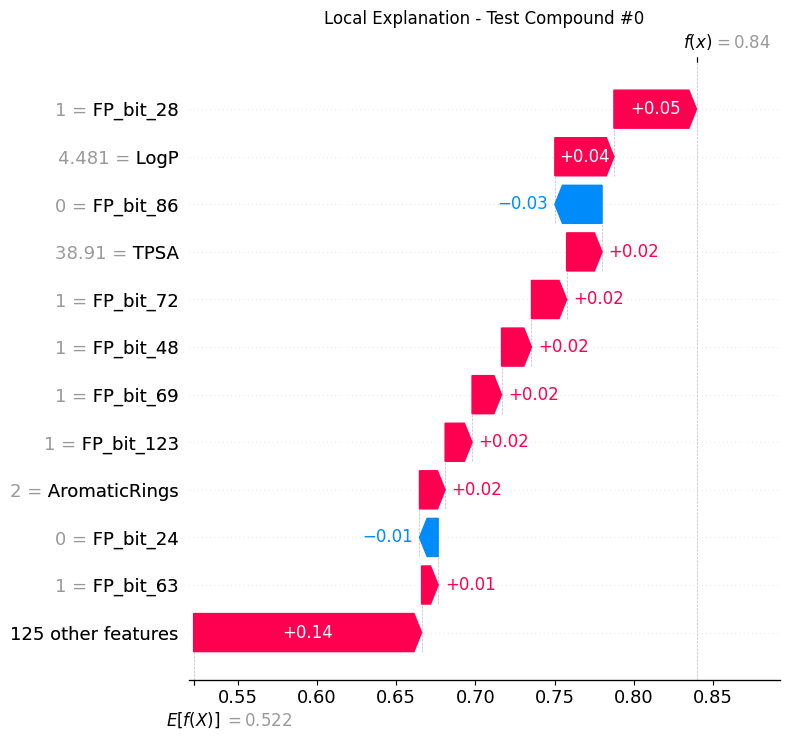


Actual label: Active
Model predicted probability of Active: 0.840

How to read this plot: starting from the base value
(average prediction), each bar shows one feature pushing
the prediction up (red, toward Active) or down (blue,
toward Inactive), ending at this specific compound's
final predicted probability.


In [10]:
# Block 11: Local explainability - why did the model predict THIS compound?

print("="*60)
print("LOCAL EXPLAINABILITY - SINGLE COMPOUND")
print("="*60)
print("This answers: for ONE specific compound, exactly which")
print("features pushed the prediction toward Active or Inactive,")
print("and by how much?")
print("="*60)

sample_idx = 0

single_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=X_test[sample_idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(single_explanation, max_display=12, show=False)
plt.title(f"Local Explanation - Test Compound #{sample_idx}")
plt.tight_layout()
plt.show()

predicted_prob = xai_model.predict_proba(X_test[sample_idx].reshape(1,-1))[0][1]
actual_label = "Active" if y_test[sample_idx] == 1 else "Inactive"

print(f"\nActual label: {actual_label}")
print(f"Model predicted probability of Active: {predicted_prob:.3f}")
print(f"\nHow to read this plot: starting from the base value")
print(f"(average prediction), each bar shows one feature pushing")
print(f"the prediction up (red, toward Active) or down (blue,")
print(f"toward Inactive), ending at this specific compound's")
print(f"final predicted probability.")

Meaning of Block 11:

Purpose: Demonstrate local explainability — explaining one individual prediction in complete detail, showing exactly which features were responsible for that specific compound's classification, in contrast to Block 10's dataset-wide view.

What data comes IN: shap_values, base_value, X_test, feature_names, xai_model from Blocks 6–9.

What comes OUT: A waterfall plot showing the exact feature-by-feature reasoning behind one specific prediction.

FEATURE DEPENDENCE ANALYSIS
Most important feature overall: FP_bit_28
Examining how its value relates to its SHAP contribution...


<Figure size 900x600 with 0 Axes>

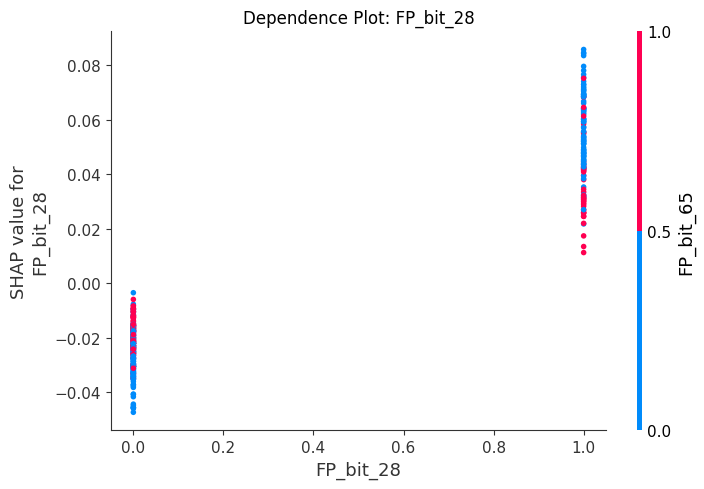


This plot shows whether HIGHER or LOWER values of
FP_bit_28 tend to push predictions toward Active,
revealing the actual shape of the relationship - not just
whether the feature matters, but HOW it matters.


In [11]:
# Block 12: Dependence plot - how does the top feature affect predictions?

print("="*60)
print("FEATURE DEPENDENCE ANALYSIS")
print("="*60)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = feature_names[top_feature_idx]

print(f"Most important feature overall: {top_feature_name}")
print(f"Examining how its value relates to its SHAP contribution...")

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    top_feature_idx, shap_values, X_test,
    feature_names=feature_names, show=False
)
plt.title(f"Dependence Plot: {top_feature_name}")
plt.tight_layout()
plt.show()

print(f"\nThis plot shows whether HIGHER or LOWER values of")
print(f"{top_feature_name} tend to push predictions toward Active,")
print(f"revealing the actual shape of the relationship - not just")
print(f"whether the feature matters, but HOW it matters.")

Meaning of Block 12:

Purpose: Investigate the specific relationship between the single most important feature and its effect on predictions — revealing not just that a feature matters, but the actual shape of that relationship (e.g., does higher molecular weight always help, or is there an optimal range?).

What data comes IN: shap_values, X_test, feature_names from Blocks 6–9.

What comes OUT: A dependence plot revealing the functional relationship between the top feature's value and its impact on predictions.

SHAP VS STANDARD FEATURE IMPORTANCE
       Feature  Standard_Importance  SHAP_Importance
     FP_bit_28             0.028647         0.032317
          LogP             0.061385         0.025134
RotatableBonds             0.038690         0.020164
         MolWt             0.048936         0.018073
     FP_bit_29             0.013217         0.015281
    FP_bit_123             0.012752         0.014388
 AromaticRings             0.021777         0.012468
     FP_bit_72             0.012212         0.012409
     FP_bit_12             0.011087         0.012218
           HBA             0.022709         0.010865


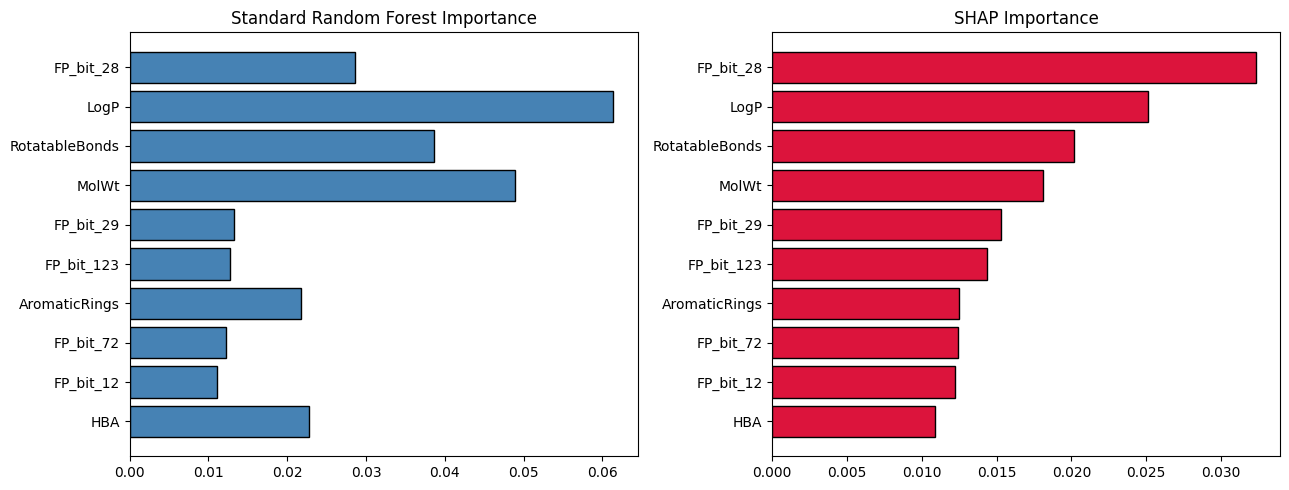


Why these can differ: standard feature importance only
measures how much a feature was used for splitting across
the whole forest, while SHAP measures actual contribution
to individual predictions - SHAP is generally considered
more reliable and consistent, especially for correlated features.


In [12]:
# Block 13: Compare SHAP-based importance with standard feature importance

print("="*60)
print("SHAP VS STANDARD FEATURE IMPORTANCE")
print("="*60)

standard_importance = xai_model.feature_importances_
shap_importance = np.abs(shap_values).mean(axis=0)

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Standard_Importance': standard_importance,
    'SHAP_Importance': shap_importance
})

top_features_by_shap = comparison_df.sort_values(
    'SHAP_Importance', ascending=False
).head(10)

print(top_features_by_shap.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_features_by_shap['Feature'],
             top_features_by_shap['Standard_Importance'],
             color='steelblue', edgecolor='black')
axes[0].set_title('Standard Random Forest Importance')
axes[0].invert_yaxis()

axes[1].barh(top_features_by_shap['Feature'],
             top_features_by_shap['SHAP_Importance'],
             color='crimson', edgecolor='black')
axes[1].set_title('SHAP Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nWhy these can differ: standard feature importance only")
print(f"measures how much a feature was used for splitting across")
print(f"the whole forest, while SHAP measures actual contribution")
print(f"to individual predictions - SHAP is generally considered")
print(f"more reliable and consistent, especially for correlated features.")

Meaning of Block 13:

Purpose: Directly compare SHAP-based importance against the standard Random Forest feature importance used throughout every earlier practical in this series, revealing that these two methods can genuinely disagree, and explaining why SHAP is generally considered the more rigorous approach.

What data comes IN: xai_model, shap_values, feature_names from Blocks 6–9.

What comes OUT: A side-by-side comparison table and chart contrasting the two importance measures.

EXPLAINABLE PREDICTION TOOL

********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO EXPLAIN A PREDICTION FOR YOUR OWN COMPOUND:                 *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-9 must already have run in this session. *
********************************************************************


Compound name entered: My_Test_Compound
SMILES entered: COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
*** WARNING: Still using DEMONSTRATION value. ***

PREDICTION: My_Test_Compound
Predicted class: ACTIVE
Probability of activity: 0.914

Generating explanation for this specific prediction...


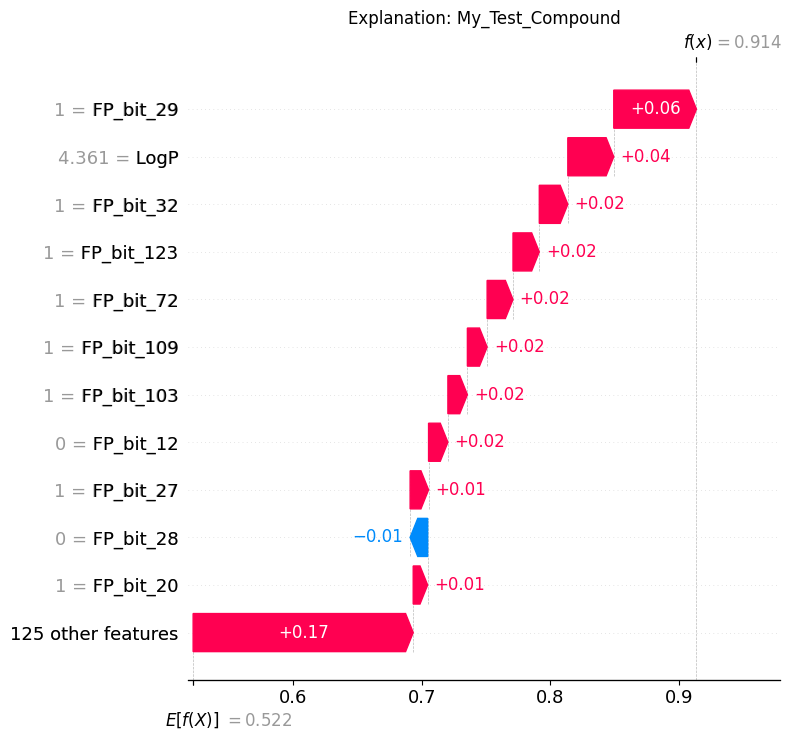


Top 5 features driving this prediction:
   Feature  SHAP_Contribution
 FP_bit_29           0.064291
      LogP           0.035717
 FP_bit_32           0.022174
FP_bit_123           0.020442
 FP_bit_72           0.020116

REMINDER: This is a computational prediction with its
reasoning shown transparently. Experimental validation
is required to confirm any result.


In [13]:
# Block 14: DEPLOYMENT BLOCK
# Get a fully explained prediction for any compound

print("="*70)
print("EXPLAINABLE PREDICTION TOOL")
print("="*70)
print("""
********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO EXPLAIN A PREDICTION FOR YOUR OWN COMPOUND:                 *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-9 must already have run in this session. *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2"
# <-- EDIT: replace with YOUR compound's SMILES (demo value is Donepezil)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\nCompound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("*** WARNING: Still using DEMONSTRATION value. ***")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES.")
else:
    new_desc = calculate_descriptors(new_compound_smiles)
    new_fp = get_fingerprint(new_compound_smiles)
    new_features = np.hstack(
        [[new_desc[c] for c in desc_cols], new_fp]
    ).reshape(1, -1)

    prediction_prob = xai_model.predict_proba(new_features)[0][1]
    prediction = "ACTIVE" if prediction_prob >= 0.5 else "INACTIVE"

    print(f"\n{'='*70}")
    print(f"PREDICTION: {new_compound_name}")
    print(f"{'='*70}")
    print(f"Predicted class: {prediction}")
    print(f"Probability of activity: {prediction_prob:.3f}")

    new_shap_full = explainer.shap_values(new_features)
    new_shap = new_shap_full[0, :, 1]

    new_explanation = shap.Explanation(
        values=new_shap,
        base_values=base_value,
        data=new_features[0],
        feature_names=feature_names
    )

    print(f"\nGenerating explanation for this specific prediction...")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(new_explanation, max_display=12, show=False)
    plt.title(f"Explanation: {new_compound_name}")
    plt.tight_layout()
    plt.show()

    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Contribution': new_shap
    }).sort_values('SHAP_Contribution', key=abs, ascending=False)

    print(f"\nTop 5 features driving this prediction:")
    print(shap_df.head(5).to_string(index=False))

    print(f"\nREMINDER: This is a computational prediction with its")
    print(f"reasoning shown transparently. Experimental validation")
    print(f"is required to confirm any result.")

Meaning of Block 14:

Purpose: A complete, self-contained explainable prediction tool — a student inputs any compound and receives not just a prediction, but a full, transparent breakdown of exactly which features drove that specific prediction, embodying the entire purpose of this practical in one usable tool.

What data comes IN: Student-typed compound name and SMILES from the input section. calculate_descriptors, get_fingerprint, desc_cols, xai_model, explainer, base_value, feature_names from all previous blocks.

What happens inside — line by line:

The warning banner and confirmation echo follow the identical safeguard pattern used throughout this practical, ensuring a student cannot mistake the demonstration compound for a genuine result without deliberately editing the input section.
new_desc = calculate_descriptors(new_compound_smiles) and new_fp = get_fingerprint(new_compound_smiles) — reuse the exact same descriptor and fingerprint functions from earlier blocks, ensuring the new compound is featurized identically to every compound the model was trained on.
prediction_prob = xai_model.predict_proba(new_features)[0][1] — the trained Random Forest produces an instant probability of activity, exactly as it would for any compound in the original dataset.
new_shap_full = explainer.shap_values(new_features) followed by new_shap = new_shap_full[0, :, 1] — computes SHAP values specifically for this one new compound, then extracts the contributions toward the "Active" class, using the exact same indexing established when the SHAP explainer was first built.
shap.Explanation(...) and shap.plots.waterfall(...) — builds and displays a waterfall plot showing exactly how each feature pushed this specific compound's prediction up or down from the base value, arriving at its final predicted probability — the same visualization style used earlier in the practical, now applied to a compound of the student's own choosing.
The final ranked table (shap_df) lists the five features that mattered most for this specific prediction, giving a quick, readable summary alongside the visual plot.

What comes OUT: A predicted activity class and probability, a waterfall plot showing the exact feature-by-feature reasoning, and a ranked list of the top contributing features — for any compound a student chooses to investigate, with a clear reminder that experimental validation remains necessary.